# Predictive Mean & Covariance Diagnostics

For each dataset folder in `results/`, produces two plots:
1. **Mean**: cross-sectional average of actual returns vs predicted mean (possibilistic masked, possibilistic power, Bayesian MA)
2. **Covariance det**: log-determinant of the predicted covariance matrix over time (same three models)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RESULTS_DIR = Path("results")

# The three predictive models to overlay
PREDICTIVE_MODELS = {
    "Poss. Masked":  "possibilistic_masked",
    "Poss. Power":   "possibilistic_power",
    "Bayesian MA":   "bayesian_averaging",
}

COLORS = {
    "Poss. Masked": "#e07b39",
    "Poss. Power":  "#5b8db8",
    "Bayesian MA":  "#5aab61",
    "Actual":       "#222222",
}

In [6]:
def smooth(x, w=21):
    """Simple centred rolling mean for visual clarity."""
    return pd.Series(x).rolling(w, center=True, min_periods=1).mean().values


def rolling_logdet(returns_arr: np.ndarray, window: int) -> np.ndarray:
    """
    Rolling sample covariance log-det of actual returns.
    Returns NaN for the first (window-1) timesteps where the window isn't full.
    """
    T, n = returns_arr.shape
    result = np.full(T, np.nan)
    for t in range(window - 1, T):
        cov = np.cov(returns_arr[t - window + 1 : t + 1].T, ddof=1)
        sign, ld = np.linalg.slogdet(cov)
        result[t] = ld if sign > 0 else np.nan
    return result


def load_folder(folder: Path):
    """Load returns and all available predictive mus/sigmas from a results folder."""
    returns = pd.read_csv(folder / "returns.csv", index_col=0)
    data = {}
    for label, stem in PREDICTIVE_MODELS.items():
        mu_path  = folder / f"{stem}_mus.npy"
        sig_path = folder / f"{stem}_sigmas.npy"
        if mu_path.exists() and sig_path.exists():
            data[label] = {
                "mus":    np.load(mu_path),    # (T, n)
                "sigmas": np.load(sig_path),   # (T, n, n)
            }
    return returns, data


def plot_dataset(folder: Path, smooth_window: int = 21, cov_window: int = 252):
    """Two-panel figure: (1) mean time series, (2) log-det covariance."""
    returns, data = load_folder(folder)
    if not data:
        print(f"  [skip] no predictive files found in {folder.name}")
        return

    T = len(returns)
    t = np.arange(T)
    actual_mean = returns.values.mean(axis=1)  # cross-sectional mean at each t

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
    title = folder.name.replace("_", " ")
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # --- Plot 1: mean ---
    ax1 = axes[0]
    ax1.plot(t, smooth(actual_mean, smooth_window),
             color=COLORS["Actual"], lw=1.2, label="Actual (smoothed)", zorder=5)
    for label, d in data.items():
        pred_mean = d["mus"].mean(axis=1)
        ax1.plot(t, smooth(pred_mean, smooth_window),
                 color=COLORS[label], lw=1.0, alpha=0.85, label=label)
    ax1.axhline(0, color="grey", lw=0.5, ls="--")
    ax1.set_ylabel("Cross-sect. mean return")
    ax1.set_title(f"Predicted vs actual mean  (rolling {smooth_window}-day smoother)")
    ax1.legend(fontsize=9, framealpha=0.8)
    ax1.tick_params(labelbottom=False)

    # --- Plot 2: log-det covariance ---
    ax2 = axes[1]

    # Actual rolling sample covariance log-det
    actual_ld = rolling_logdet(returns.values, window=cov_window)
    ax2.plot(t, actual_ld,
             color=COLORS["Actual"], lw=1.2, label=f"Actual ({cov_window}-day rolling)", zorder=5)

    # Predicted log-dets
    for label, d in data.items():
        _, logdet = np.linalg.slogdet(d["sigmas"])
        ax2.plot(t, smooth(logdet, smooth_window),
                 color=COLORS[label], lw=1.0, alpha=0.85, label=label)

    ax2.set_ylabel("log det Σ")
    ax2.set_xlabel("Trading day")
    ax2.set_title(f"Log-determinant of covariance  (predicted: {smooth_window}-day smoother | actual: {cov_window}-day rolling sample)")
    ax2.legend(fontsize=9, framealpha=0.8)

    plt.show()
    return fig

In [7]:
folders = sorted([f for f in RESULTS_DIR.iterdir() if f.is_dir()])
print(f"Found {len(folders)} dataset folders")
for f in folders:
    print(" ", f.name)

Found 23 dataset folders
  10_Industry_Portfolios_Daily_equal_weighted
  10_Industry_Portfolios_Daily_value_weighted
  10_Portfolios_Formed_on_ME_size_equal_weighted
  10_Portfolios_Formed_on_ME_size_value_weighted
  10_Portfolios_Formed_on_booktomarket_equal_weighted
  10_Portfolios_Formed_on_booktomarket_value_weighted
  10_Portfolios_Prior_momentum_equal_weighted
  10_Portfolios_Prior_momentum_value_weighted
  10_Portfolios_Prior_str_equal_weighted
  10_Portfolios_Prior_str_value_weighted
  10_Portfolios_ltr_equal_weighted
  10_Portfolios_ltr_value_weighted
  6_Portfolios_size_btm_equal_weighted
  6_Portfolios_size_ltr_equal_weighted
  6_Portfolios_size_ltr_value_weighted
  6_Portfolios_size_momentum_equal_weighted
  6_Portfolios_size_momentum_value_weighted
  6_Portfolios_size_str_equal_weighted
  6_Portfolios_size_str_value_weighted
  break
  iid
  mr
  reg


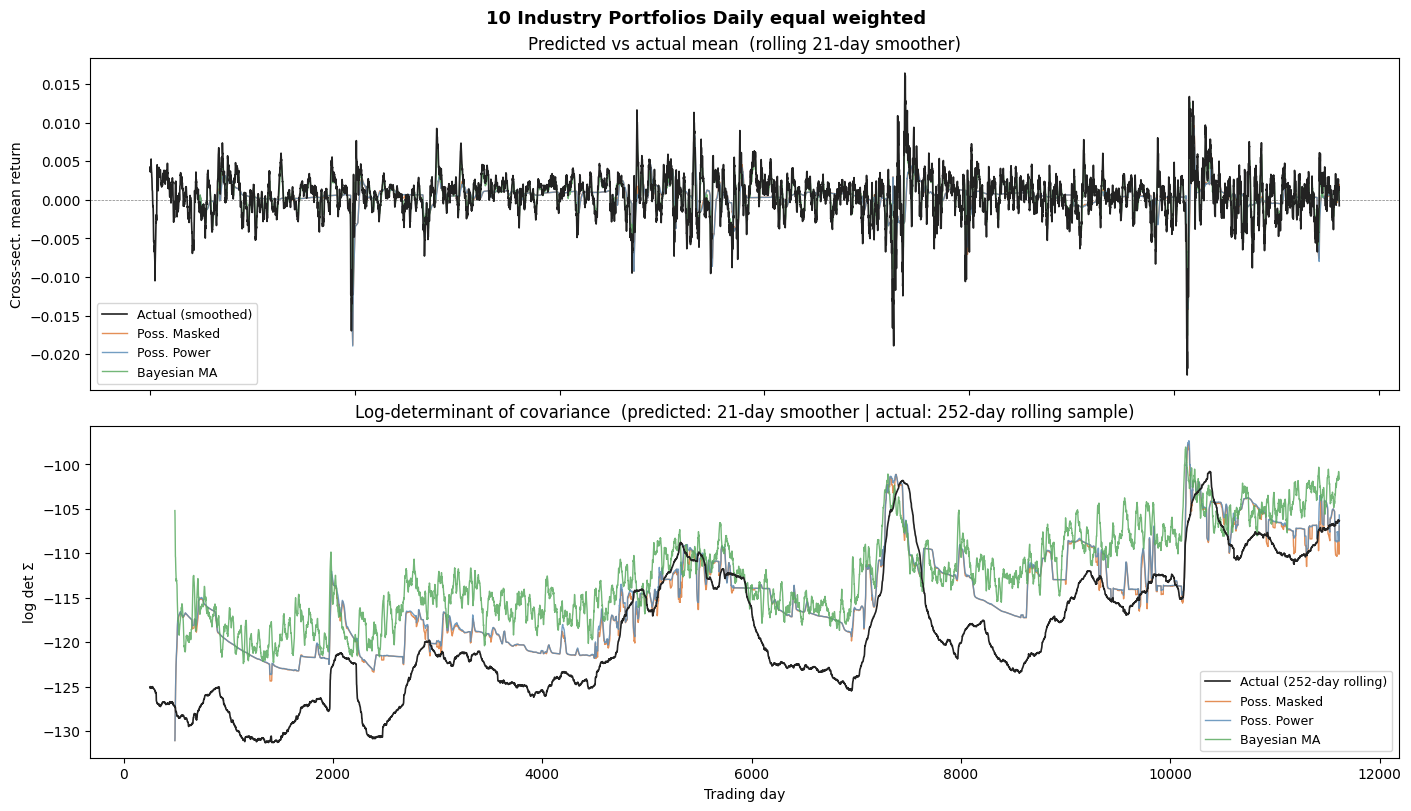

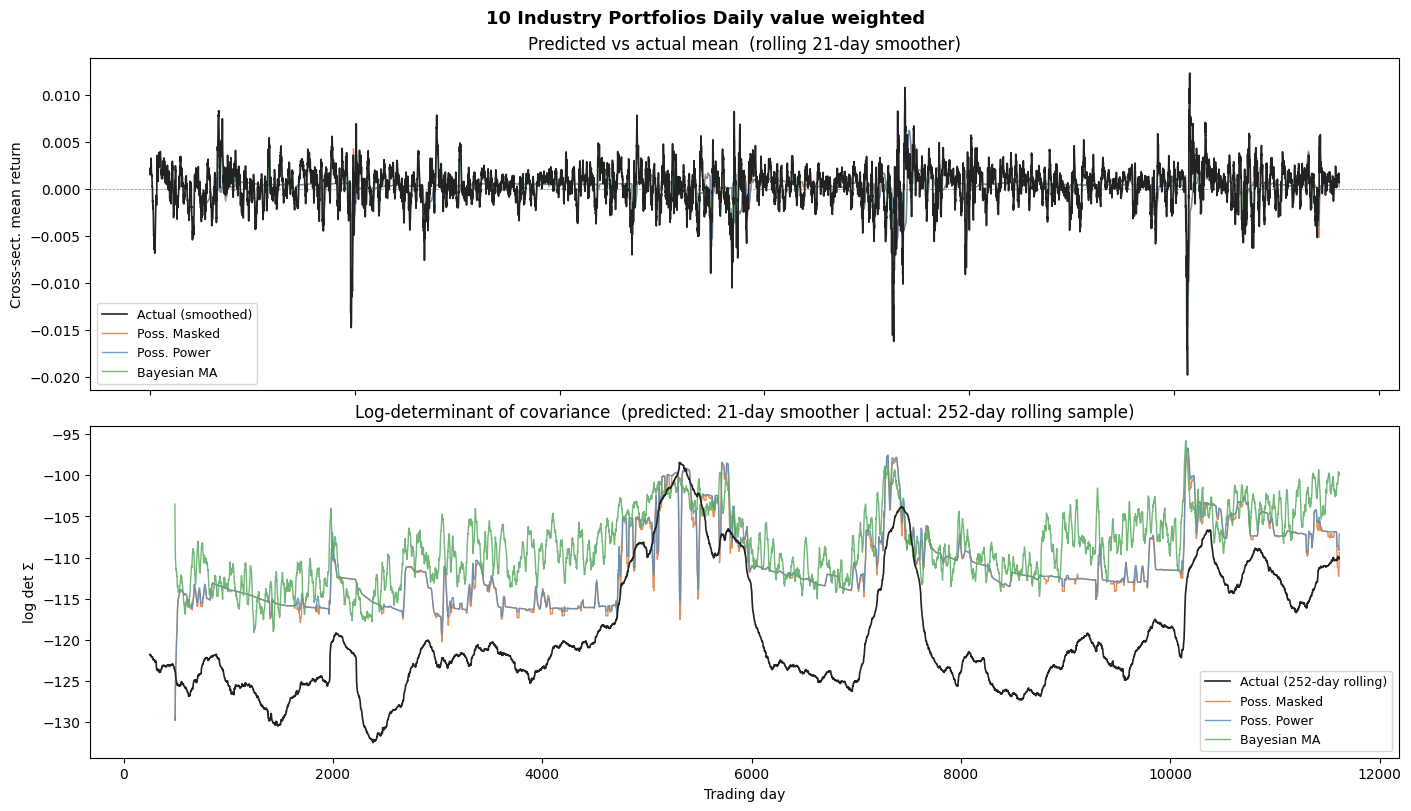

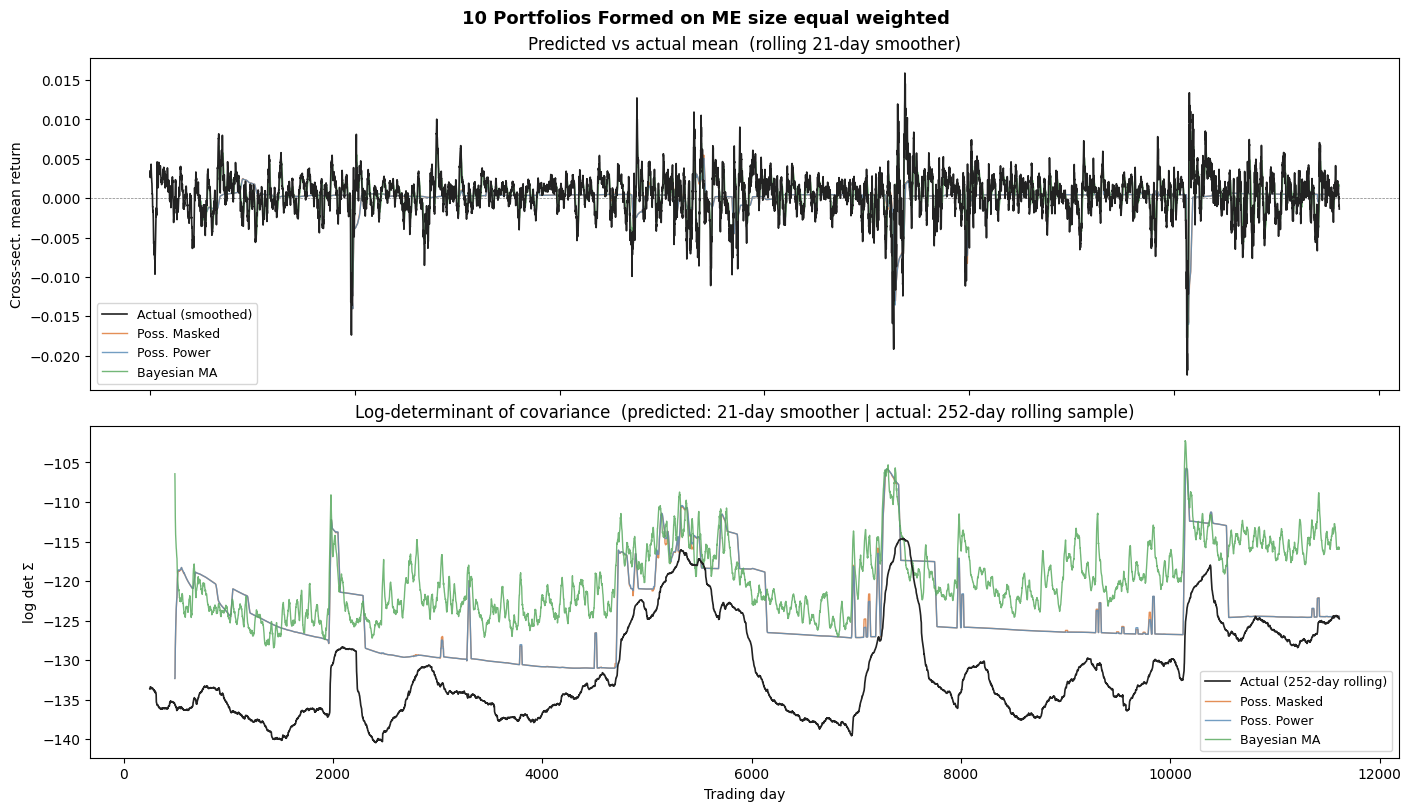

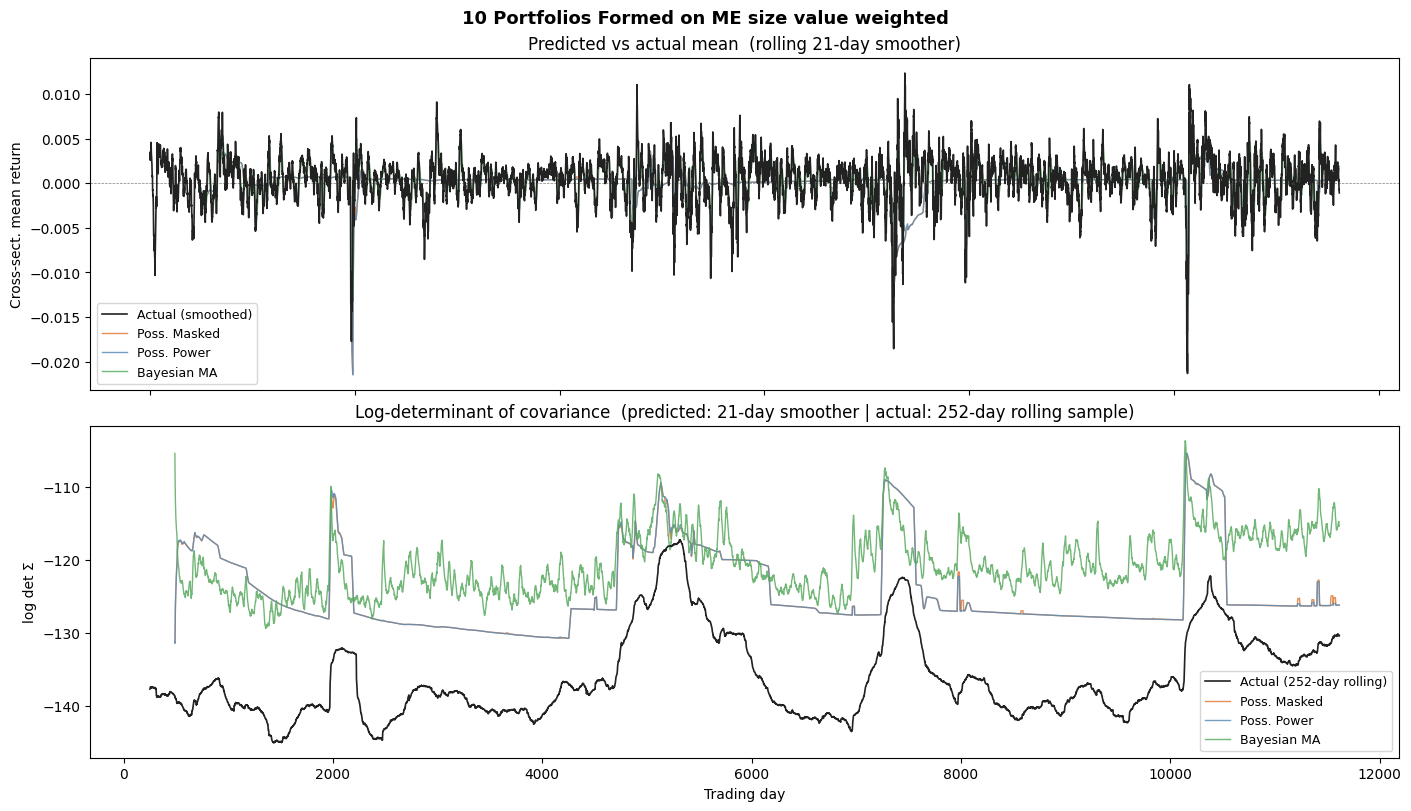

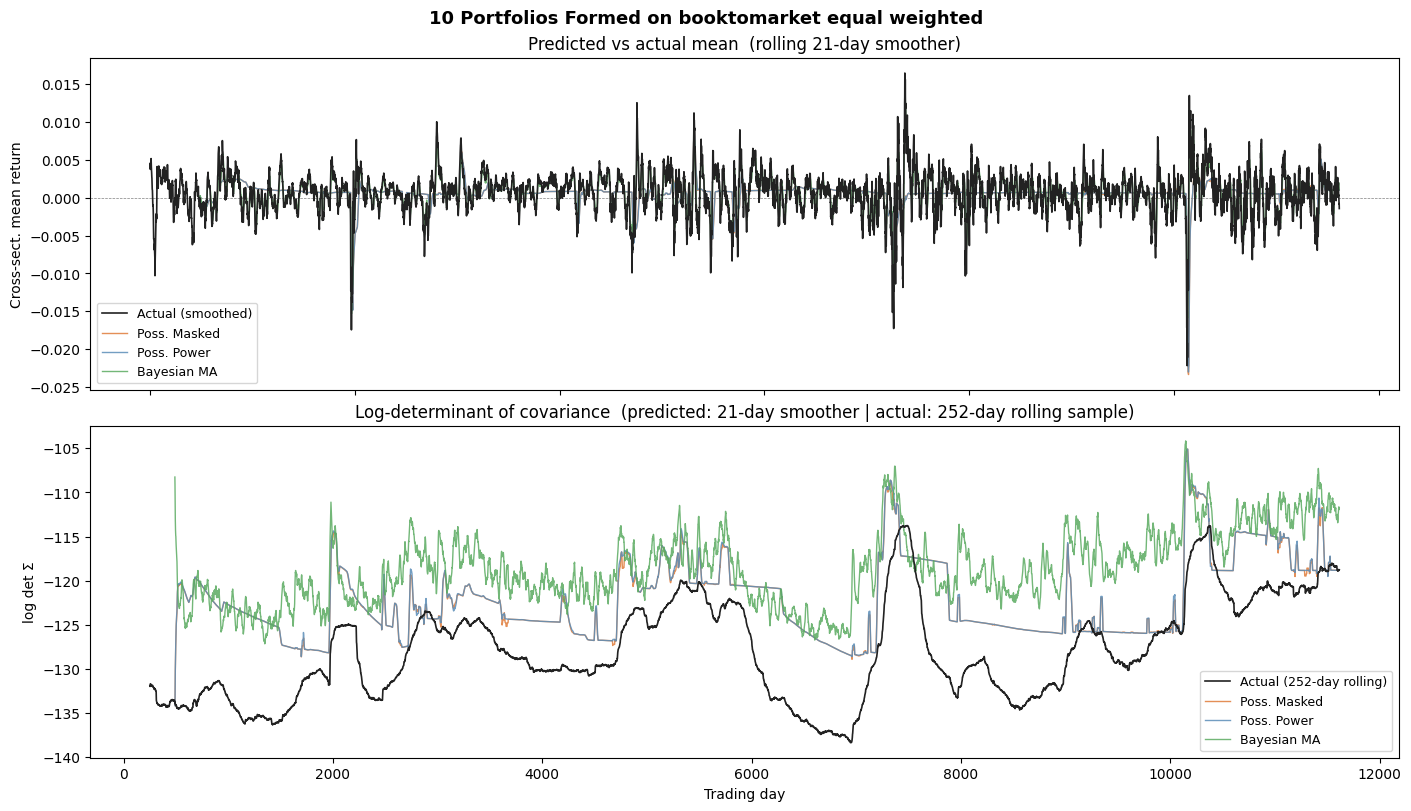

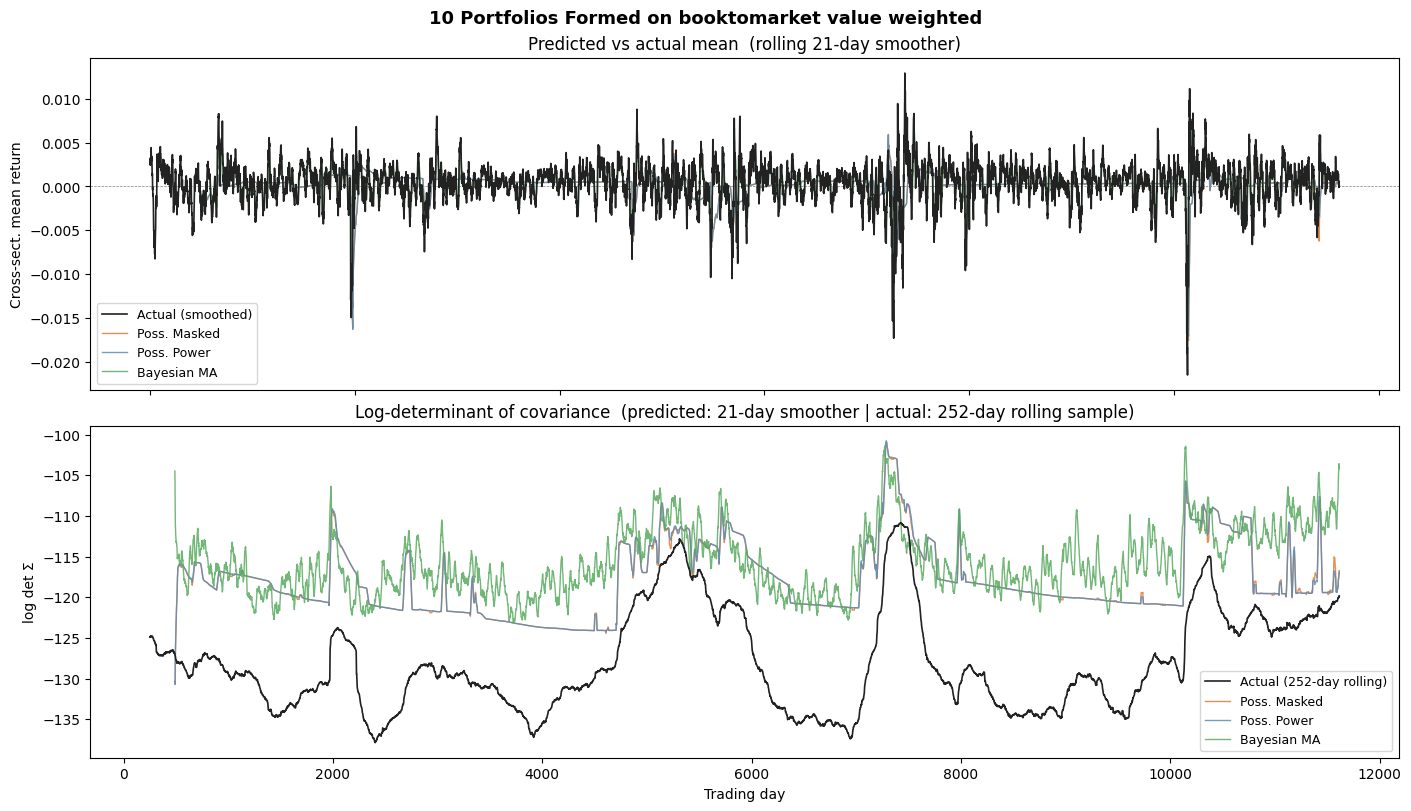

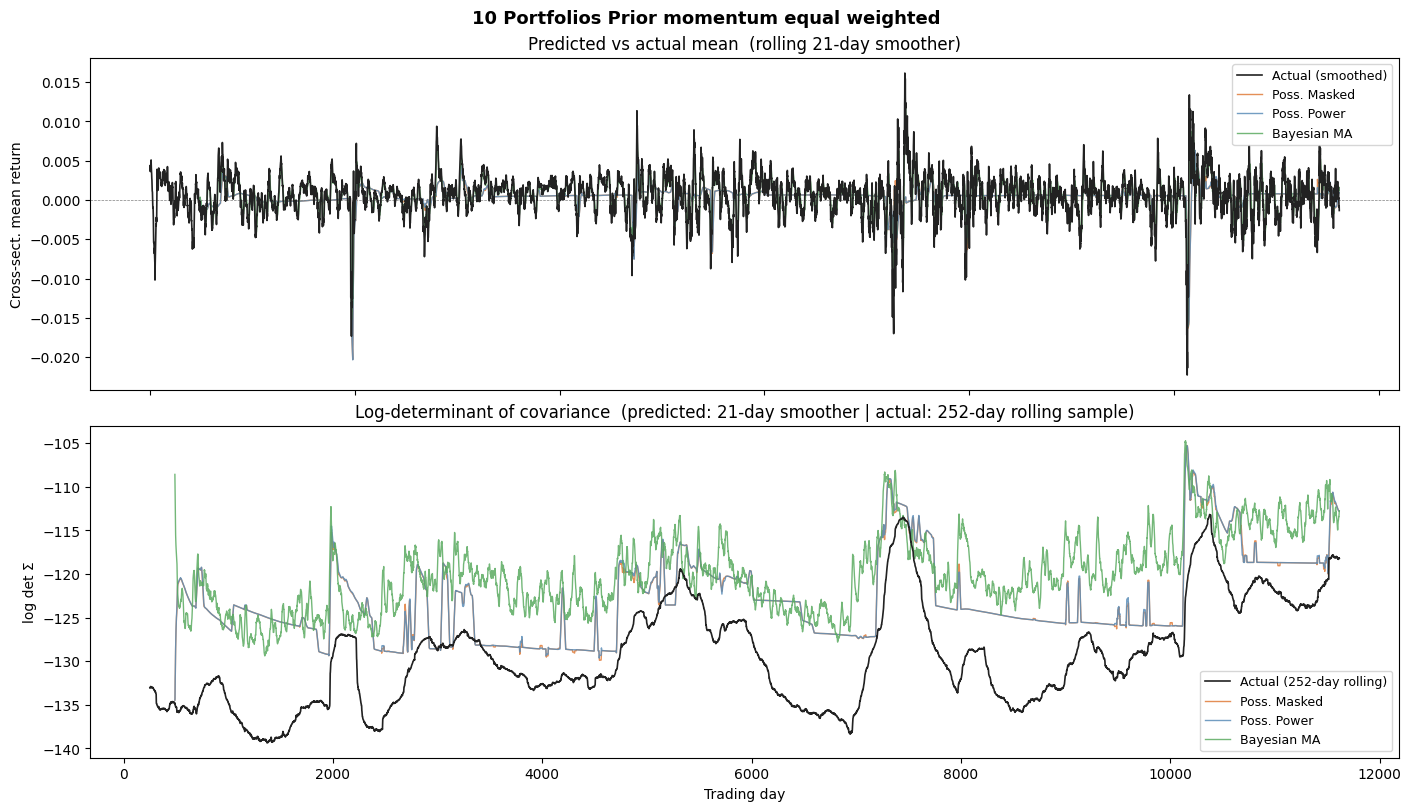

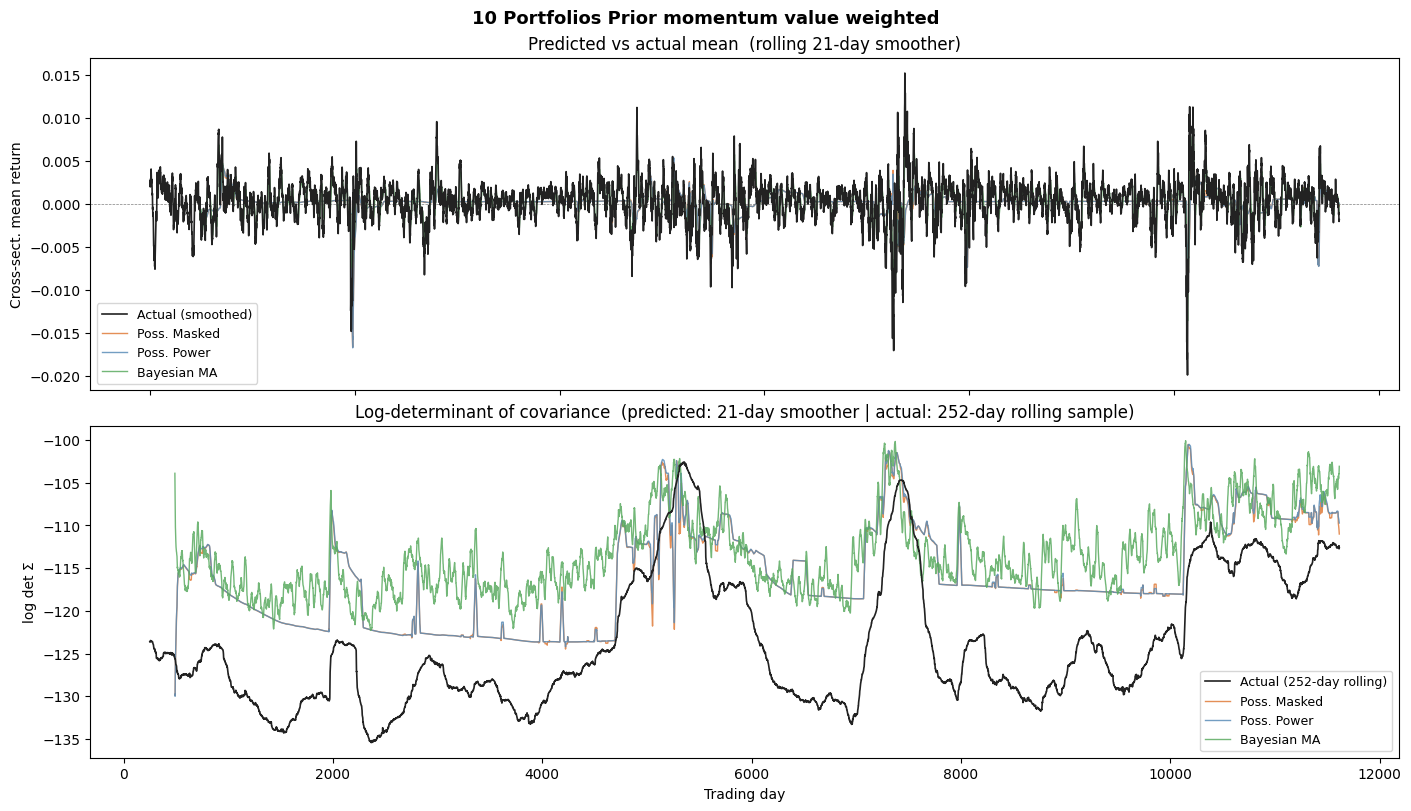

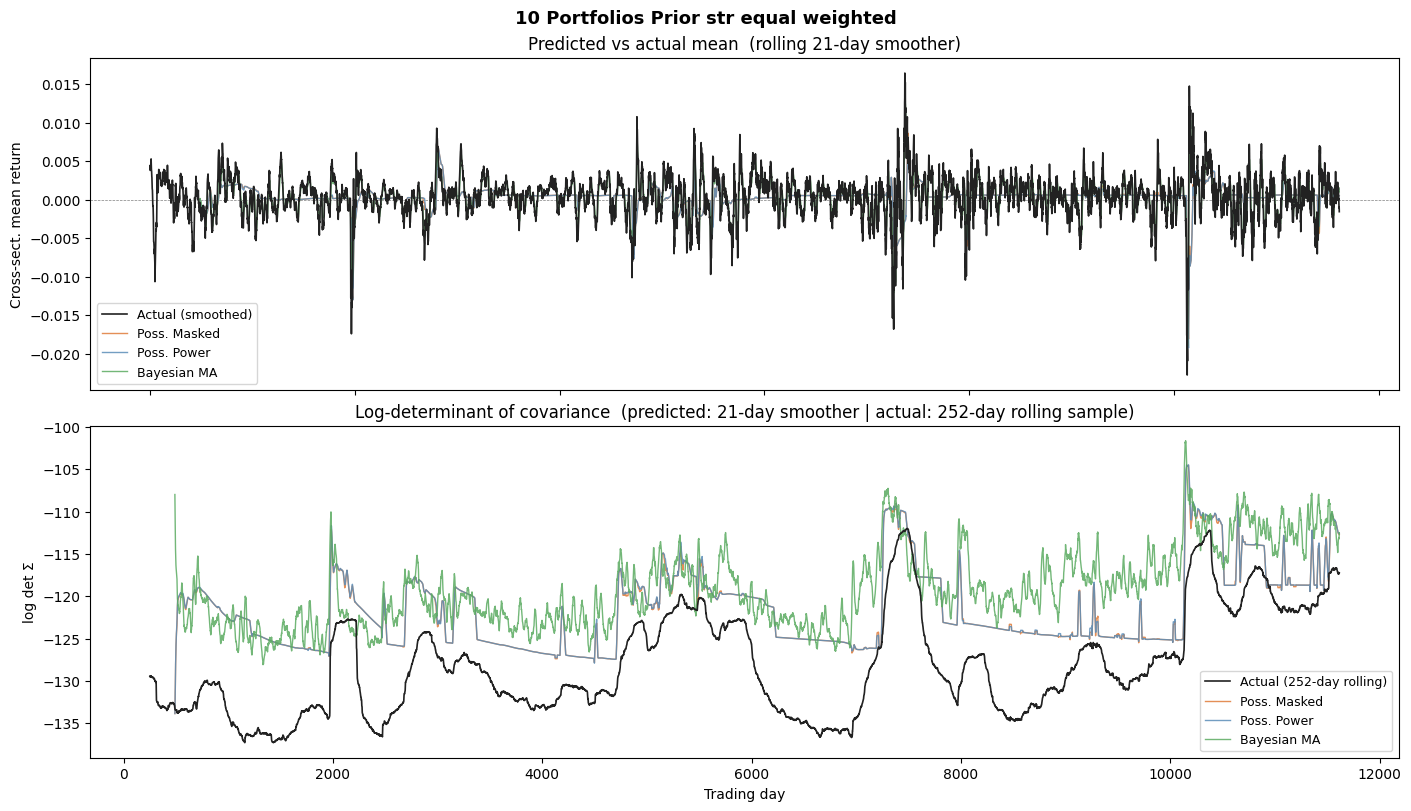

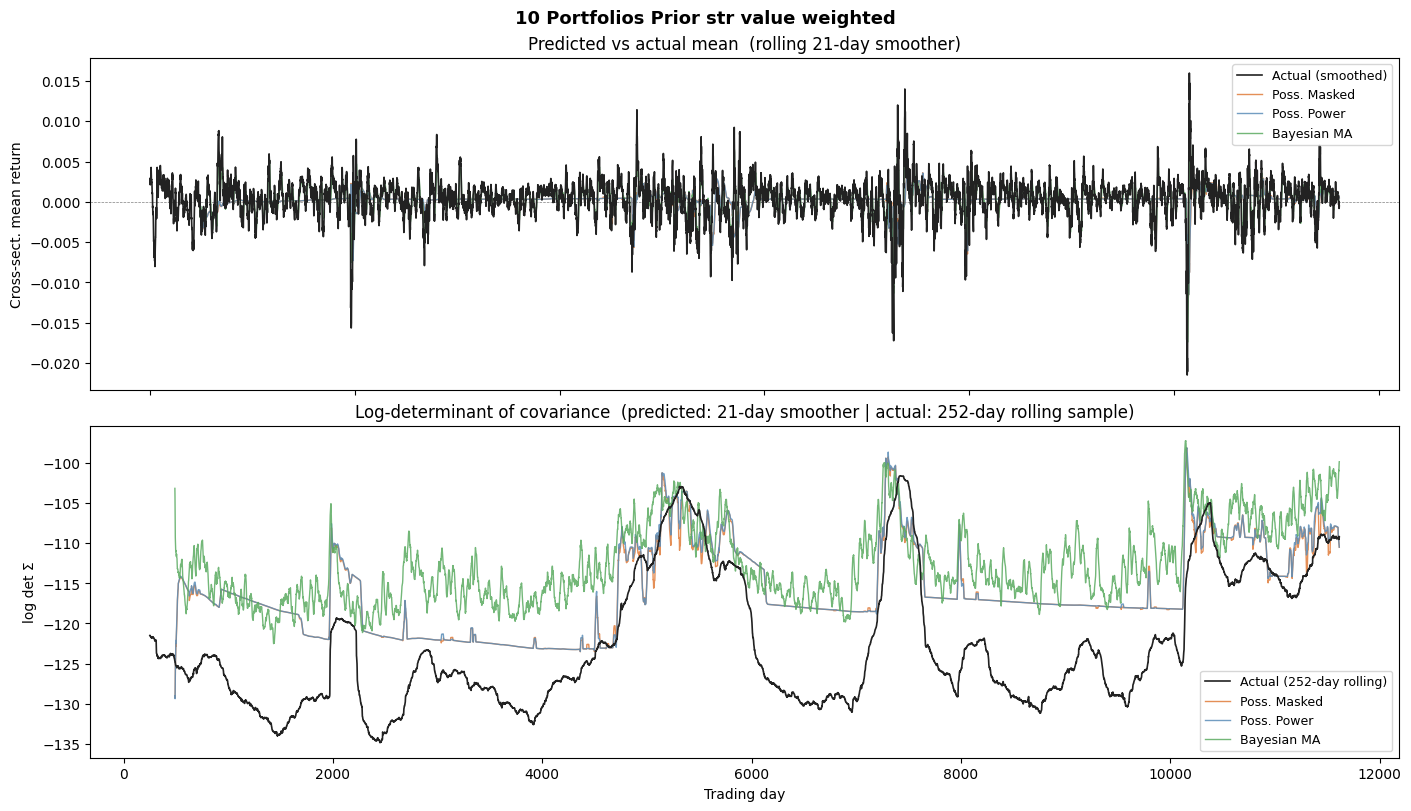

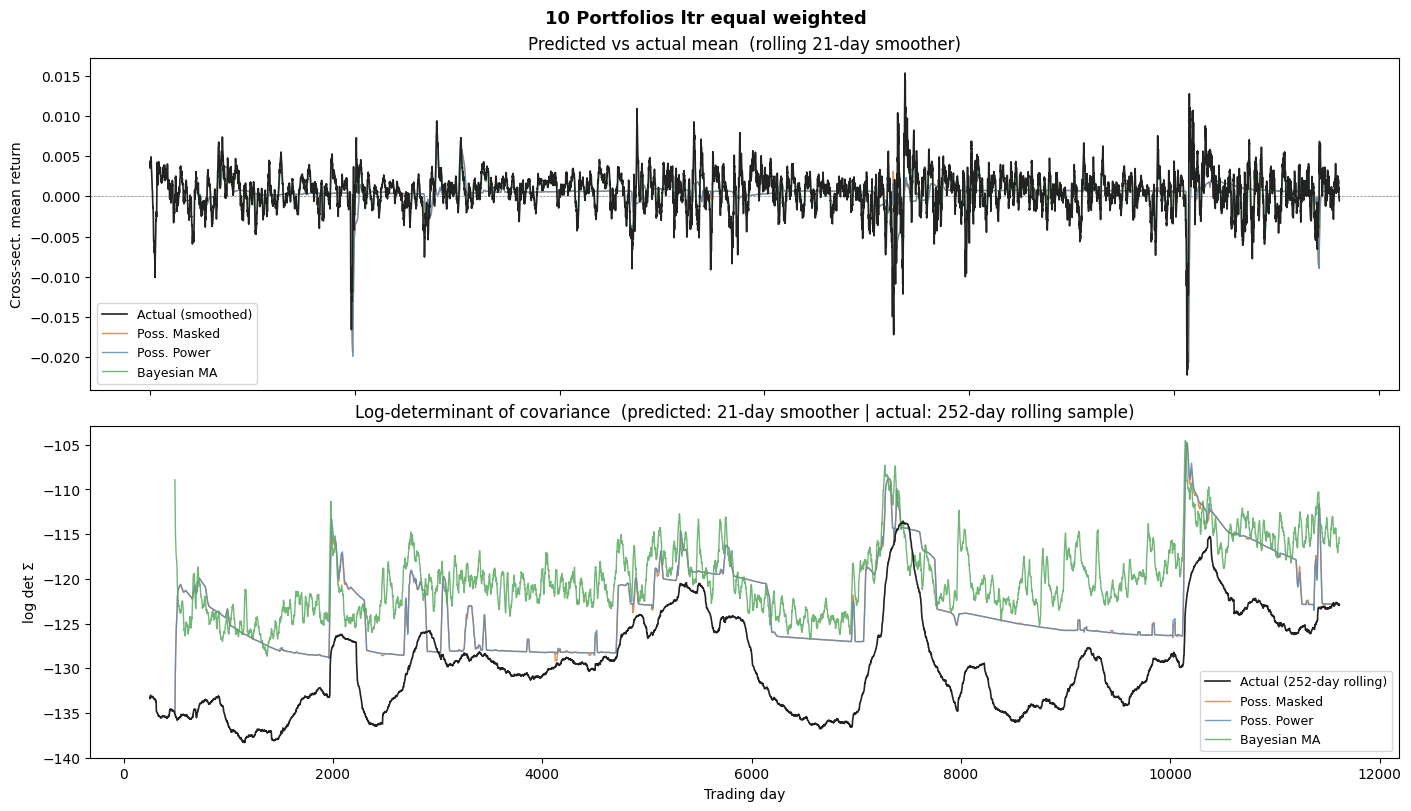

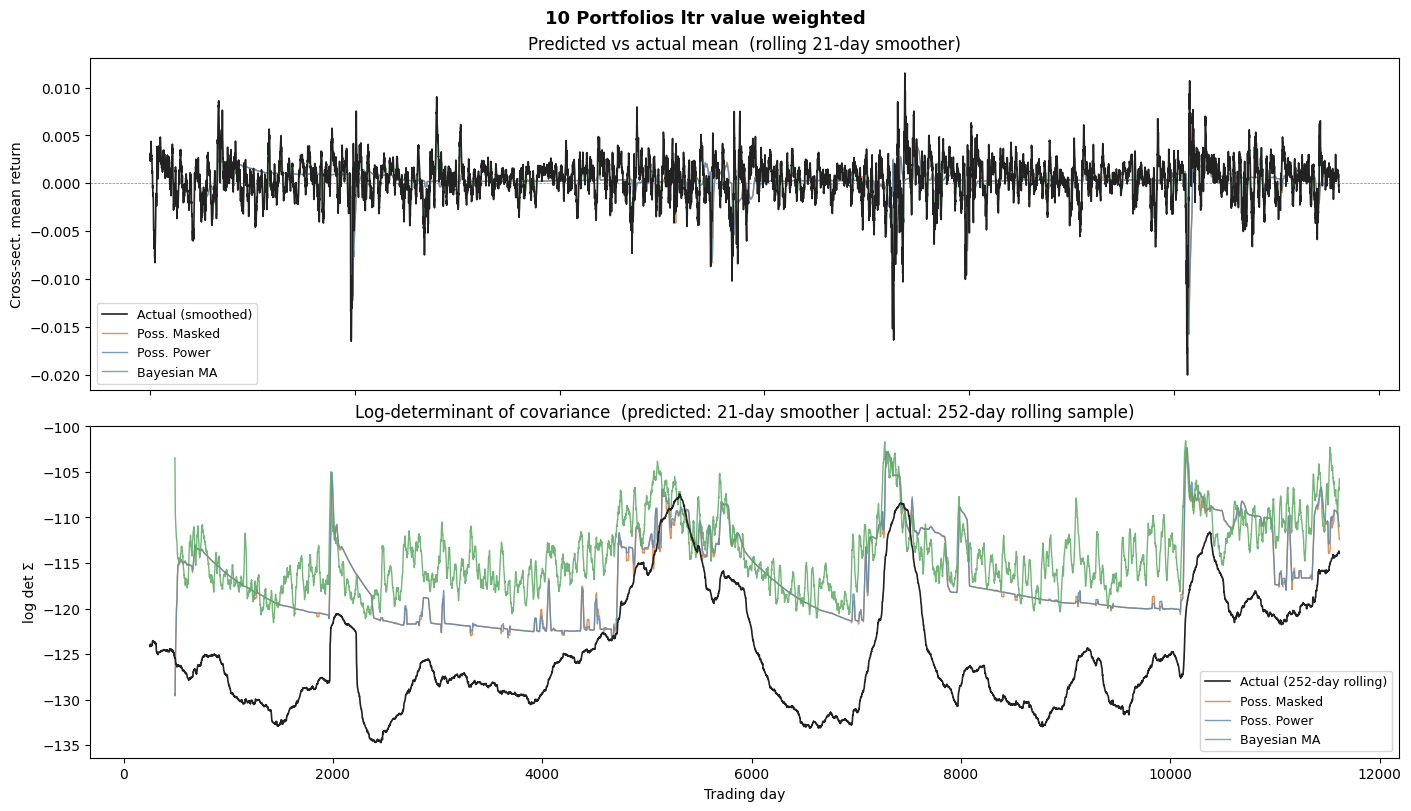

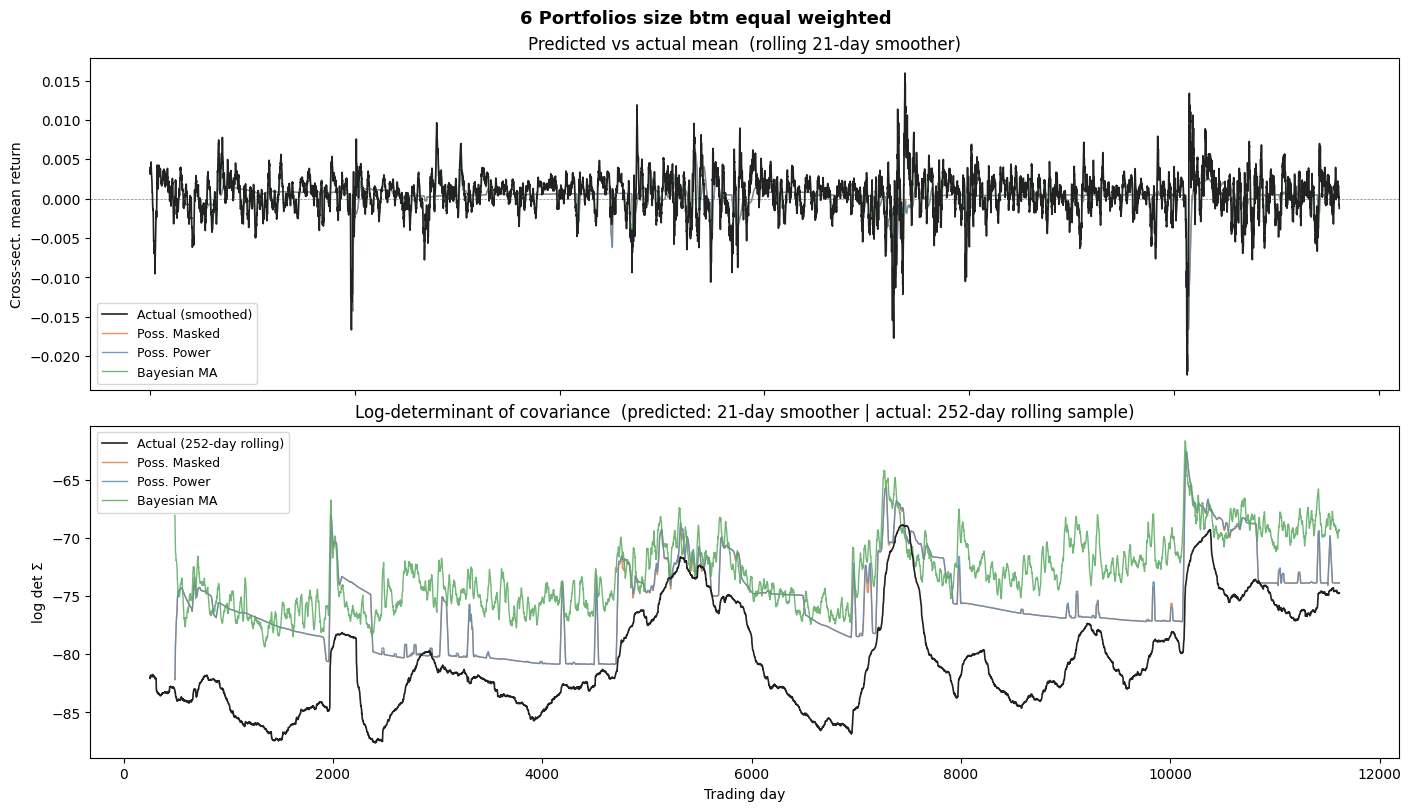

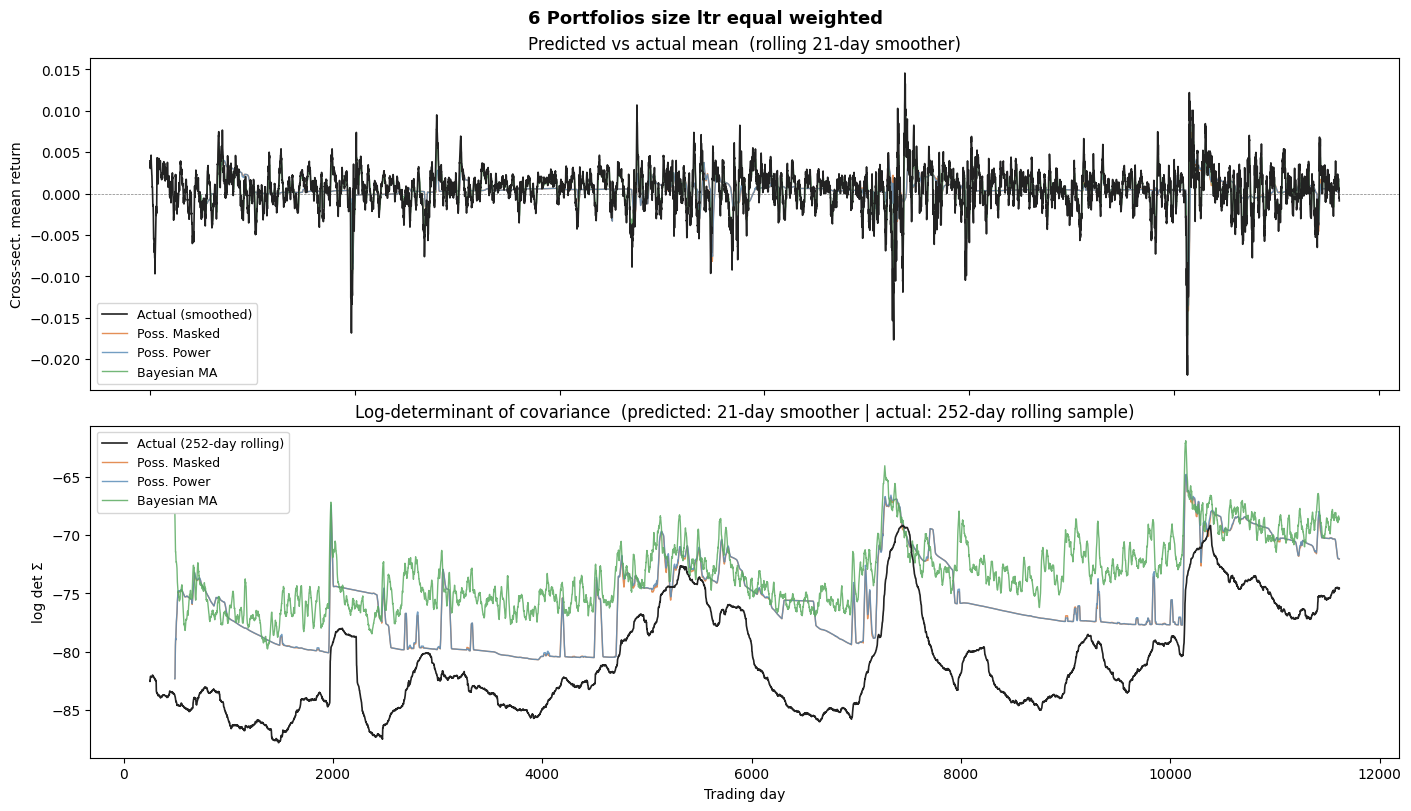

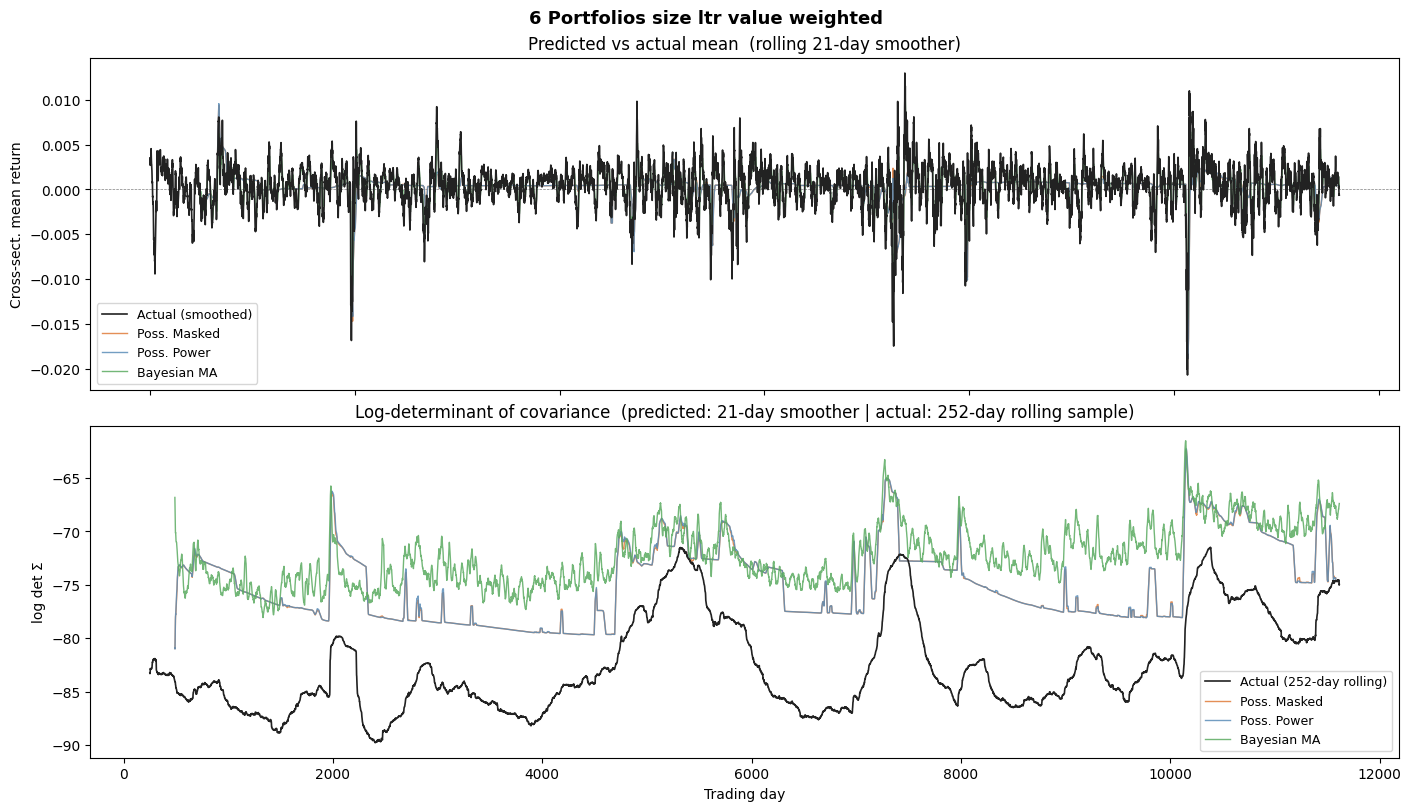

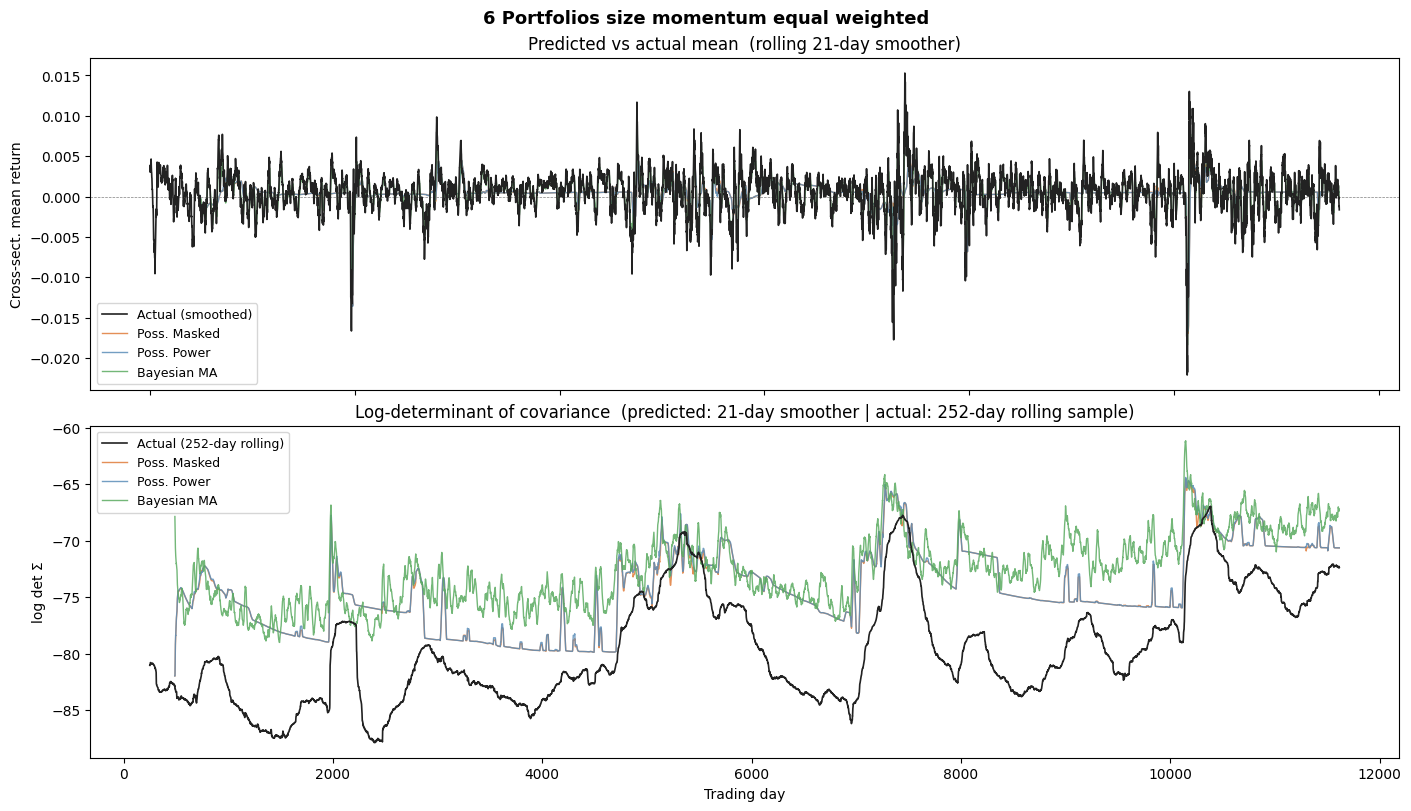

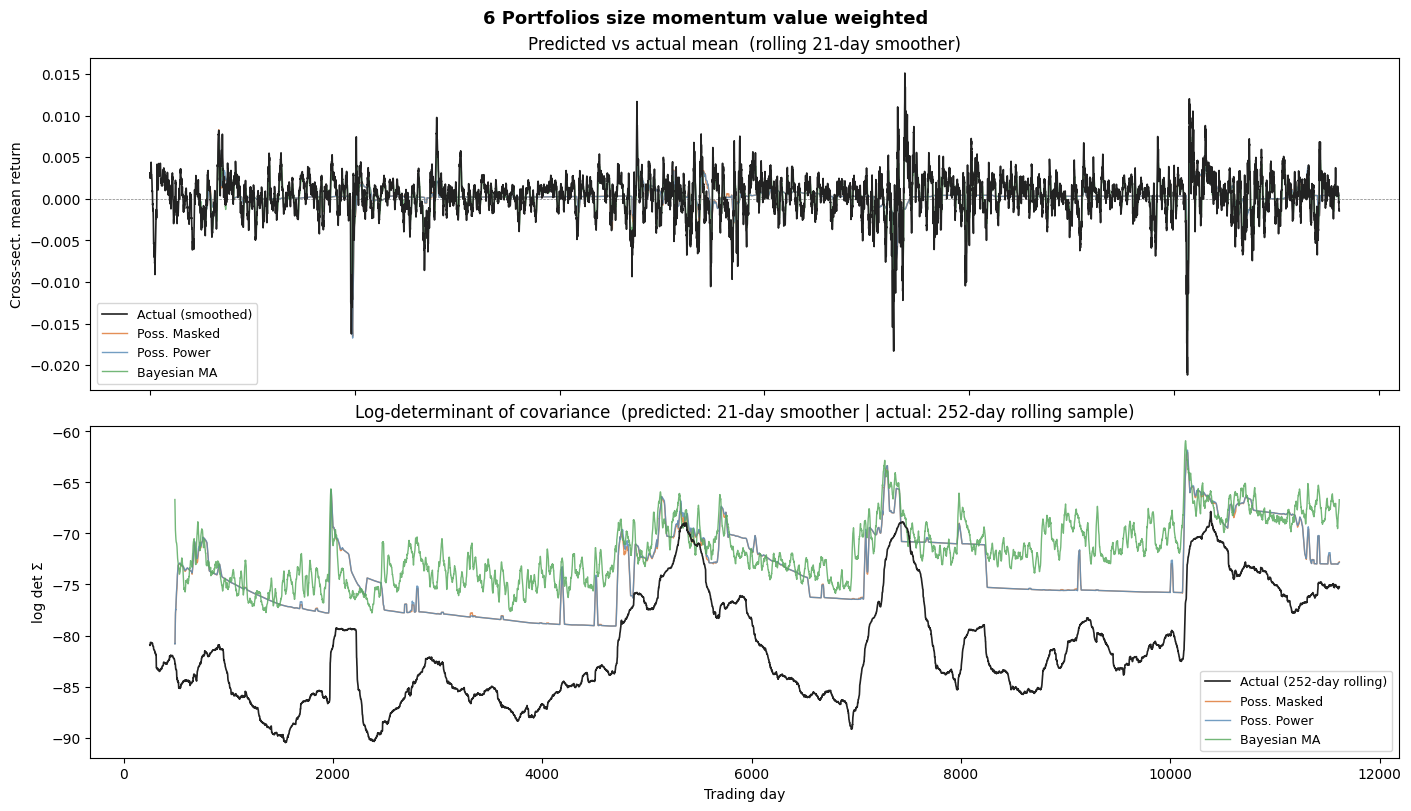

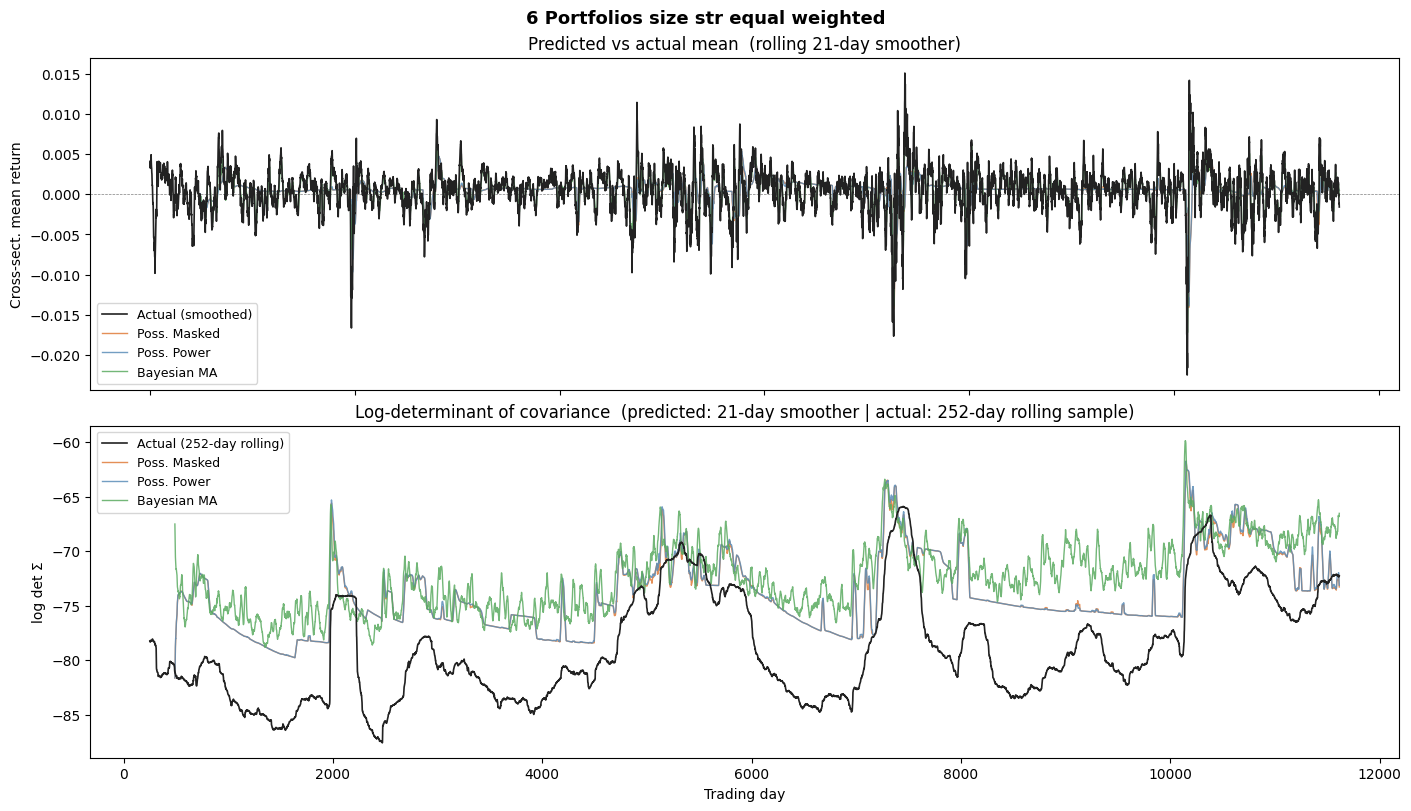

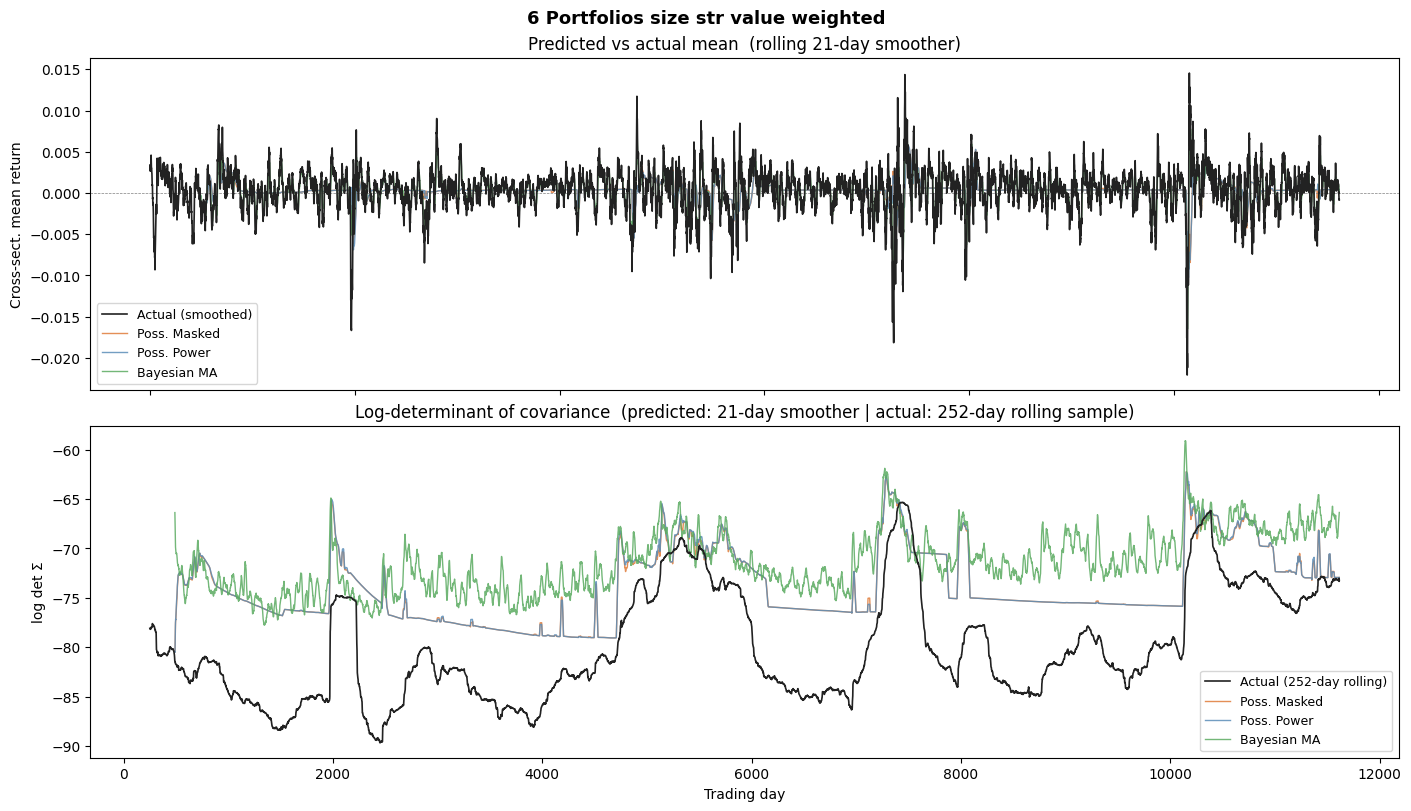

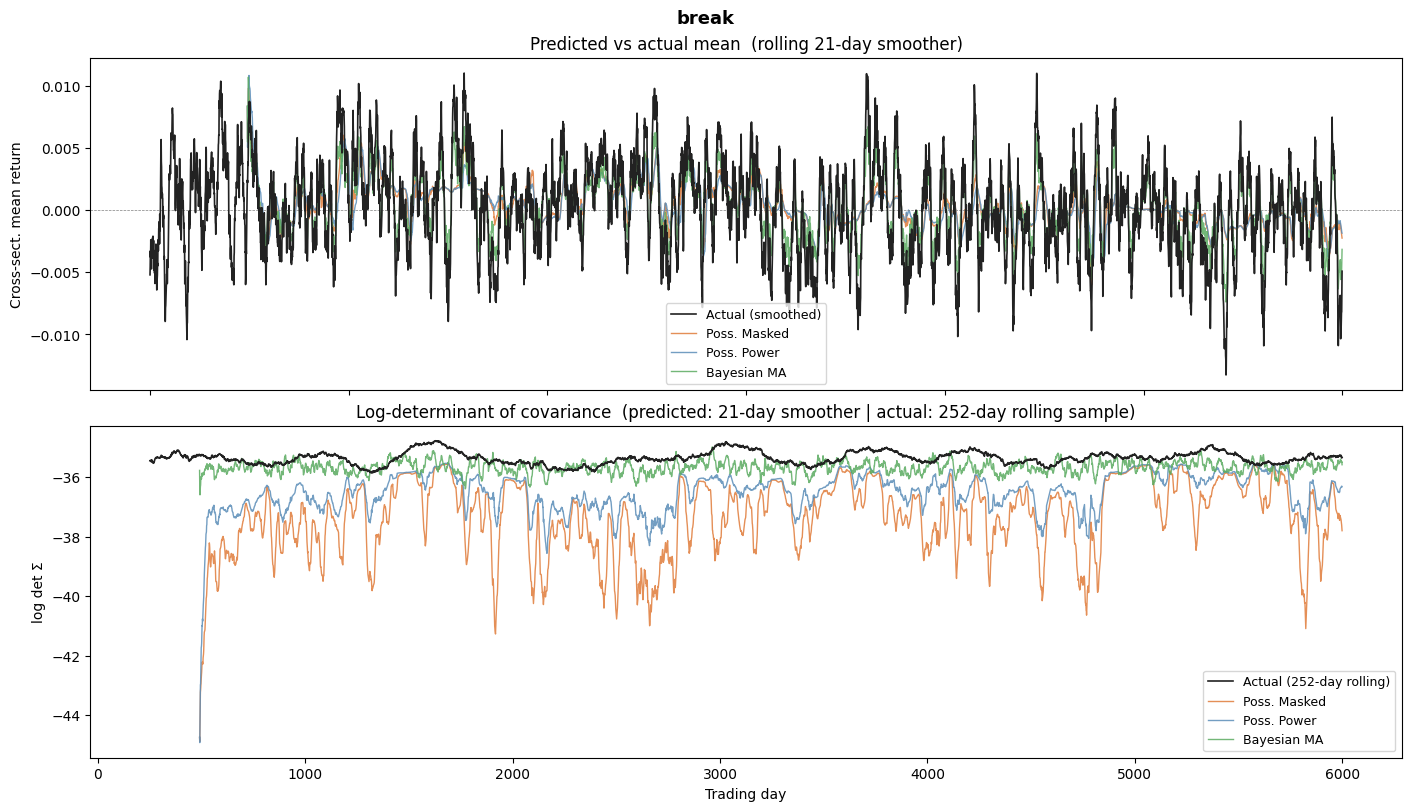

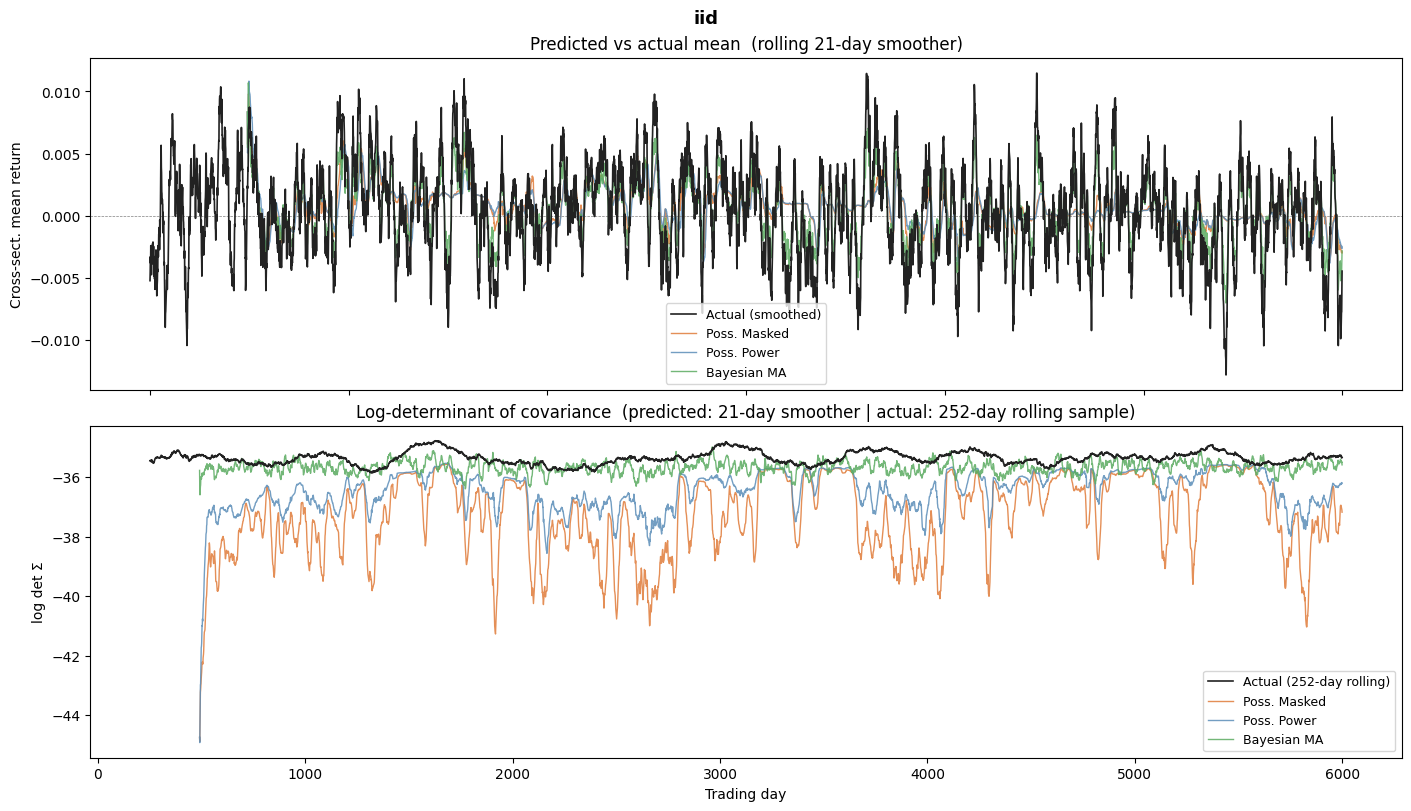

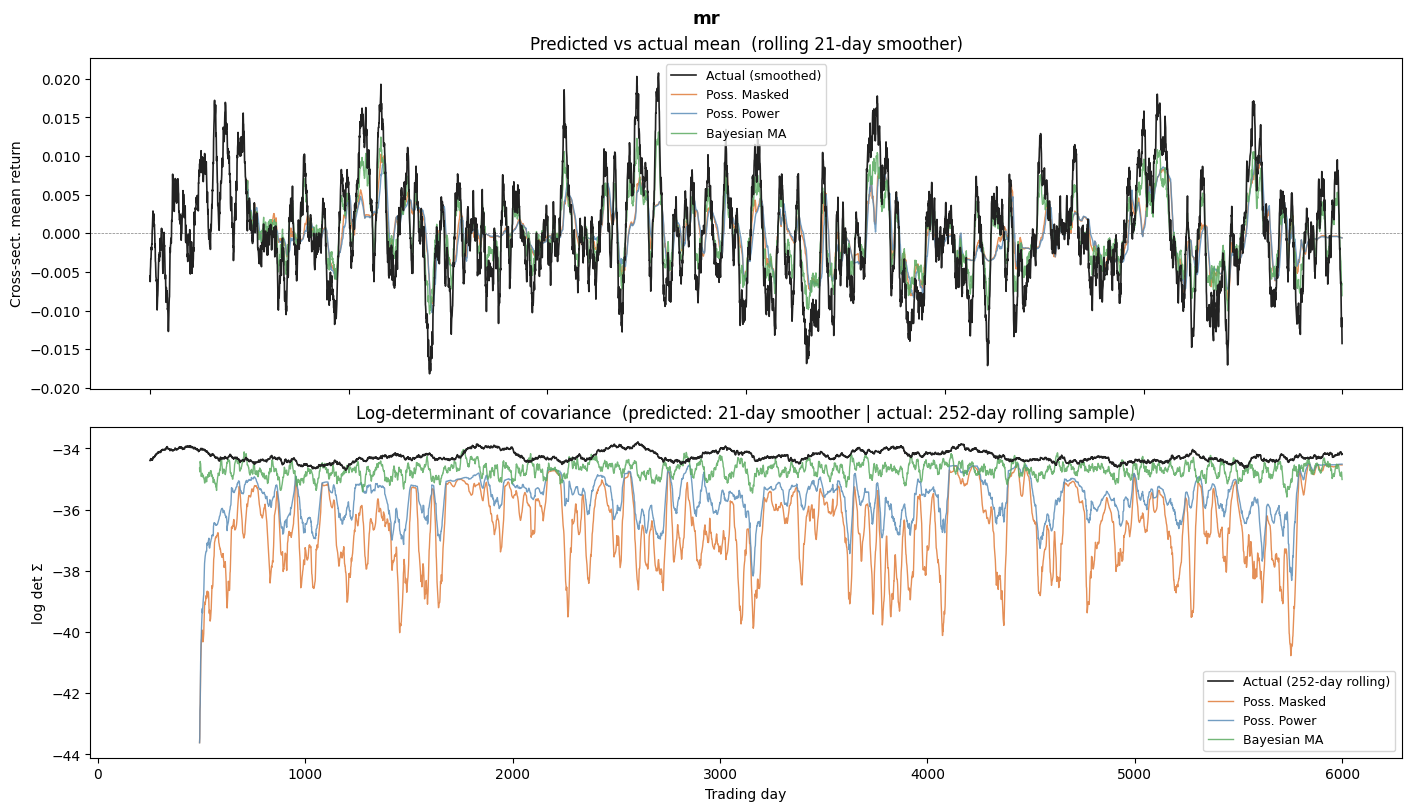

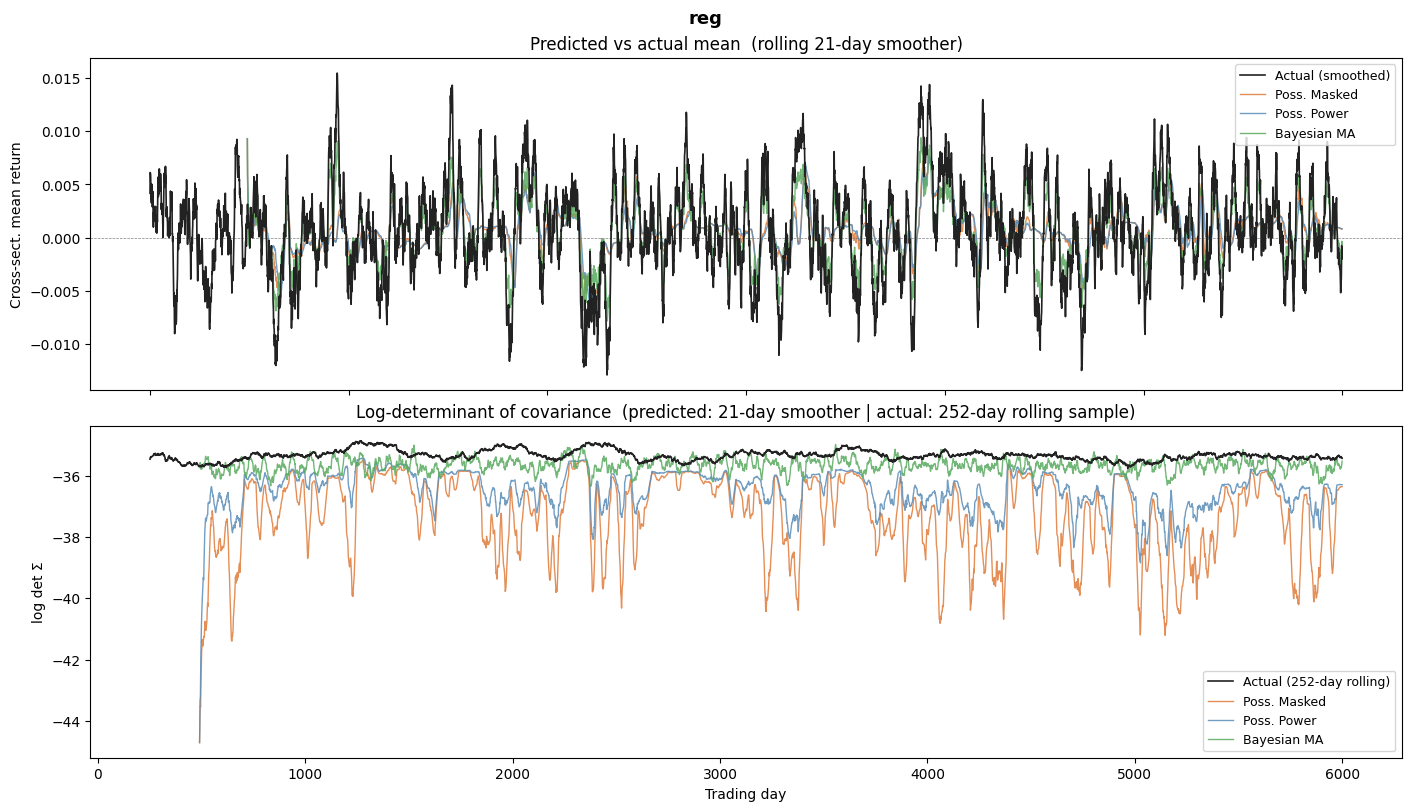

In [8]:
SMOOTH_WINDOW = 21   # smoother applied to predicted series (set 1 to disable)
COV_WINDOW    = 252  # rolling window for actual sample covariance (trading days)

for folder in folders:
    plot_dataset(folder, smooth_window=SMOOTH_WINDOW, cov_window=COV_WINDOW)

We can also see that the weights and the positions taken by the possibilistic case that they are far more conservative than the probabilistic bayesian case.

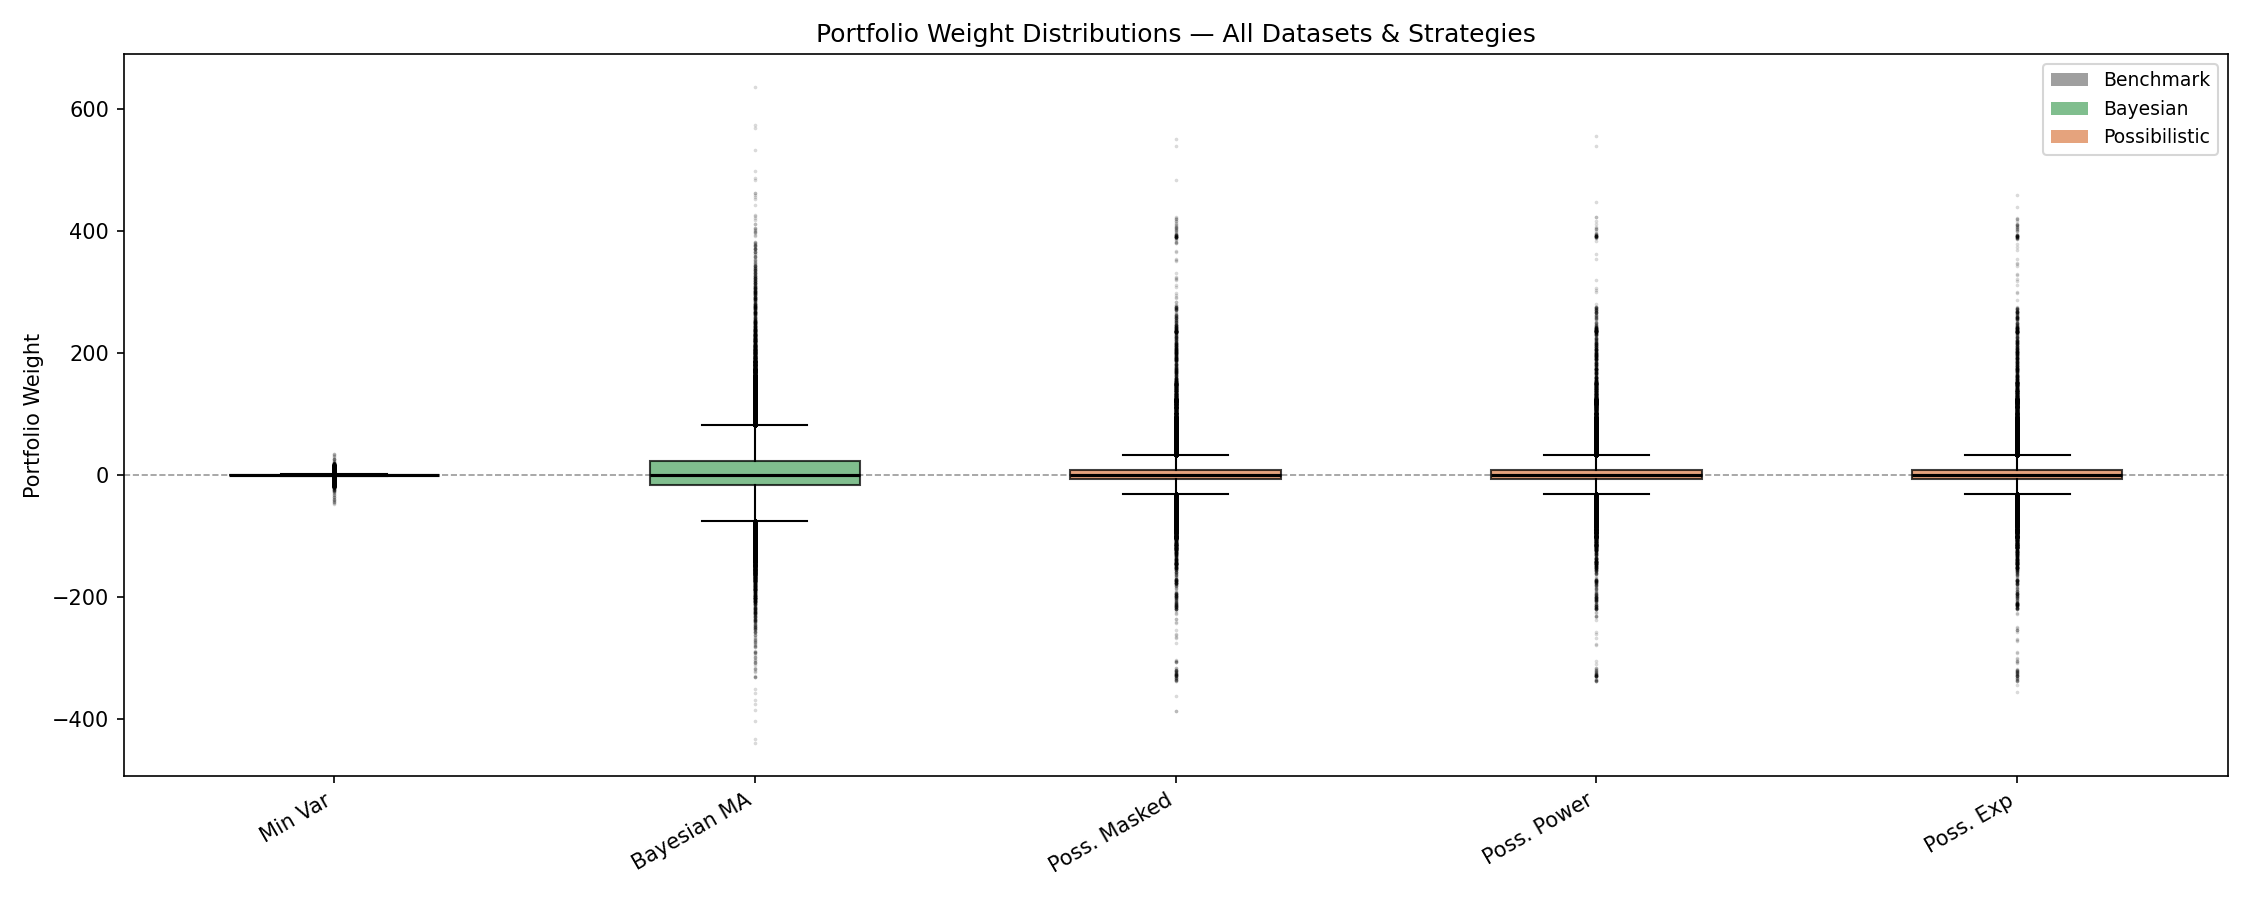

In [11]:
from IPython.display import Image
Image("src/weight_distributions.png")
